# 03 RNN / LSTM / GRU (Part C)

This notebook handles the recurrent-model workflow: preprocessing for the sequence models, training and evaluating Vanilla RNN, LSTM, and GRU, showing performance reports in the notebook, and displaying learning-curve plots directly in the notebook. Only checkpoints are saved to disk.

In [1]:
from __future__ import annotations

import json
import os
import random
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.train import train_model, result_to_export_row


In [2]:
RANDOM_SEED = 42
MAX_LEN = 455
VOCAB_SIZES = [10000, 20000, 30000]
SELECTED_VOCAB_SIZE = 30000
EPOCHS = 3
LEARNING_RATE = 1e-3
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT = 0.5
CHECKPOINT_DIR = Path("../checkpoints")
FIGURES_DIR = CHECKPOINT_DIR / "figures"
EXPORT_PATH = CHECKPOINT_DIR / "recurrent_exports.json"
MISCLASSIFIED_PATH = CHECKPOINT_DIR / "best_model_misclassified_examples.csv"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device


device(type='mps')

## Required Recurrent Experiments

This notebook runs the full Part C workflow fixed-configuration variant comparison, embedding-dimension ablation for the best recurrent variant, and a 1-vs-2 recurrent-layer ablation for that same variant.


,model,variant,accuracy,precision,recall,f1,time_per_epoch_sec,checkpoint_path,figure_path
0,Vanilla RNN,rnn,0.6677,0.675602,0.6452,0.660051,115.844432,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...
1,LSTM,lstm,0.7757,0.769081,0.7880,0.778425,135.377521,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...
2,GRU,gru,0.8268,0.783878,0.9024,0.838974,145.570058,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...


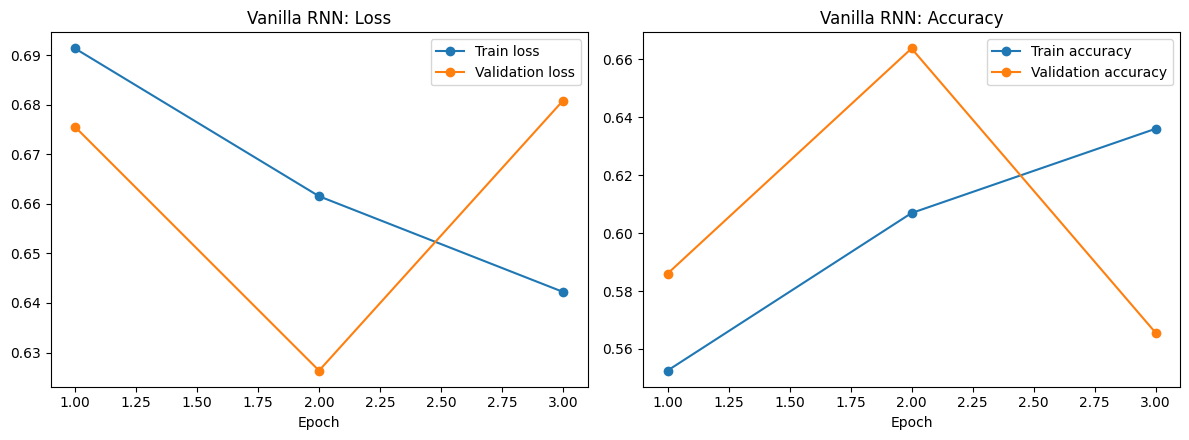

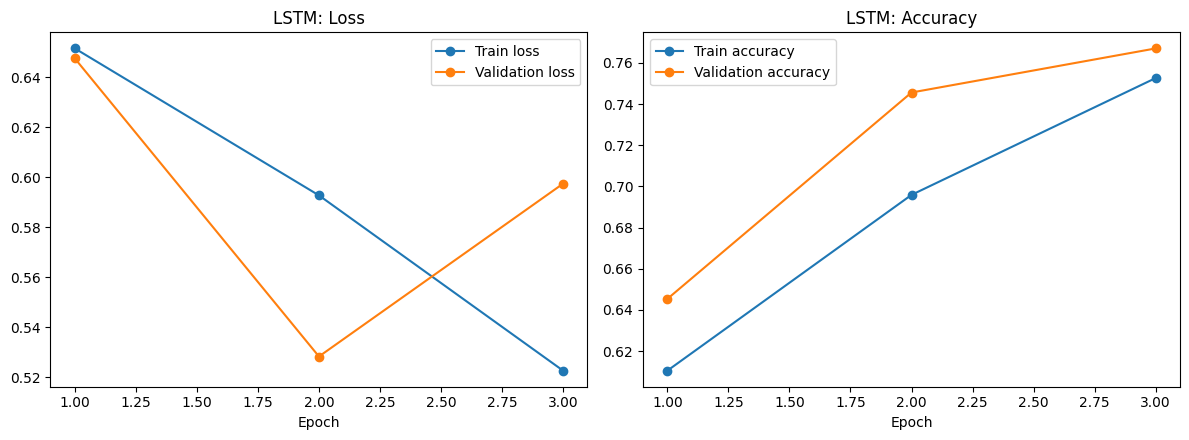

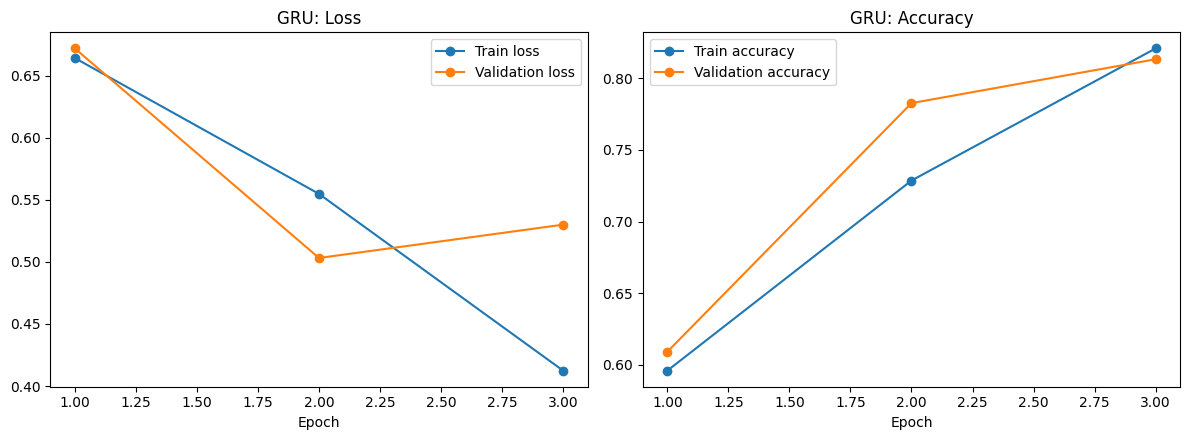

In [3]:
variant_results = []
for variant in ["rnn", "lstm", "gru"]:
    variant_results.append(
        train_model(
            variant=variant,
            embed_dim=EMBED_DIM,
            hidden_dim=HIDDEN_DIM,
            num_layers=1,
            epochs=EPOCHS,
            dropout=DROPOUT,
            vocab_size=SELECTED_VOCAB_SIZE,
            vocab_sizes=VOCAB_SIZES,
            learning_rate=LEARNING_RATE,
            max_len=MAX_LEN,
            device=device,
            checkpoint_name=f"{variant}_best.pt",
            curve_title=variant.upper() if variant != "rnn" else "Vanilla RNN",
            figure_name=f"{variant}_learning_curves.png",
        )
    )

variant_summary_df = pd.DataFrame([result_to_export_row(row) for row in variant_results])
variant_summary_df


In [4]:
best_recurrent_result = max(variant_results, key=lambda row: row["accuracy"])
best_variant = best_recurrent_result["variant"]

pd.DataFrame(
    [
        {
            "best_variant": best_variant,
            "model": best_recurrent_result["model"],
            "accuracy": best_recurrent_result["accuracy"],
            "precision": best_recurrent_result["precision"],
            "recall": best_recurrent_result["recall"],
            "f1": best_recurrent_result["f1"],
            "time_per_epoch_sec": best_recurrent_result["time_per_epoch_sec"],
        }
    ]
)


,best_variant,model,accuracy,precision,recall,f1,time_per_epoch_sec
0,gru,GRU,0.8268,0.783878,0.9024,0.838974,145.570058


## DataLoaders

,model,variant,embed_dim,accuracy,precision,recall,f1,time_per_epoch_sec,checkpoint_path,figure_path
0,GRU,gru,64,0.8550,0.840691,0.8760,0.857982,122.813716,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...
1,GRU,gru,128,0.8191,0.776660,0.8958,0.831987,141.953526,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...
2,GRU,gru,256,0.8394,0.827101,0.8582,0.842364,221.449593,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...


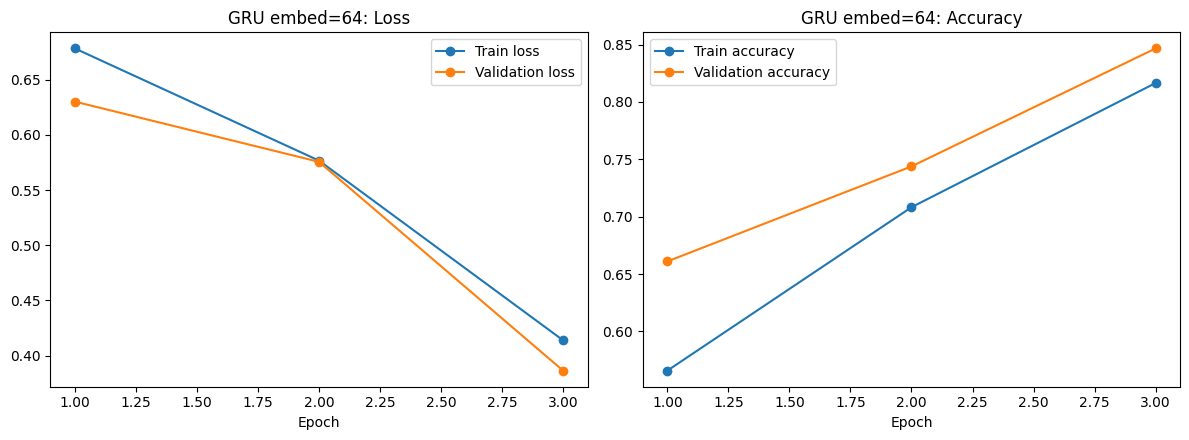

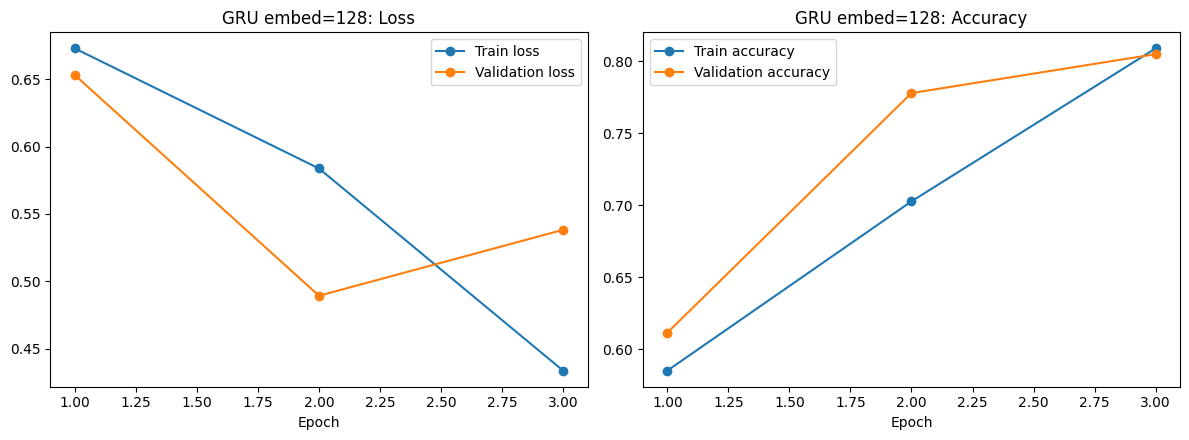

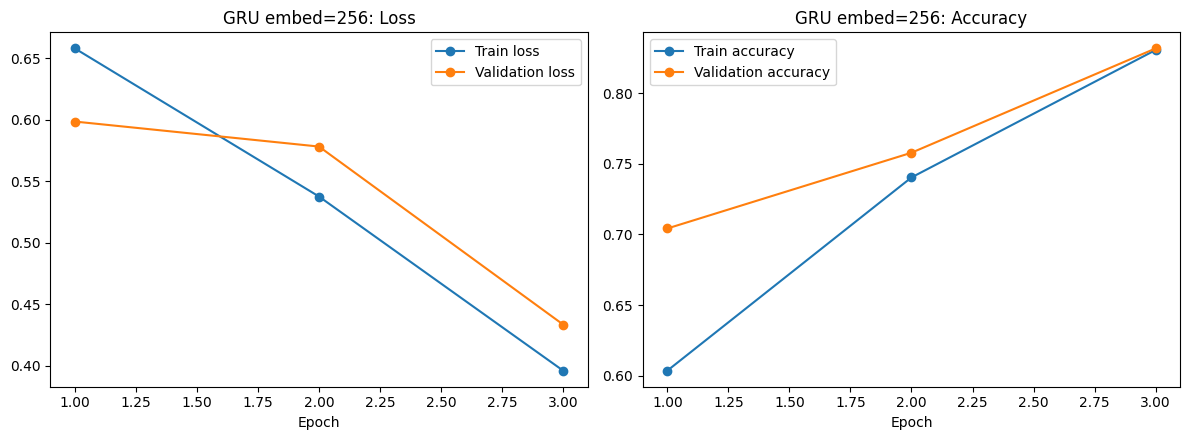

In [5]:
embedding_results = []
embedding_dims = [64, 128, 256]
for embed_dim in embedding_dims:
    embedding_results.append(
        train_model(
            variant=best_variant,
            embed_dim=embed_dim,
            hidden_dim=HIDDEN_DIM,
            num_layers=1,
            epochs=EPOCHS,
            dropout=DROPOUT,
            vocab_size=SELECTED_VOCAB_SIZE,
            vocab_sizes=VOCAB_SIZES,
            learning_rate=LEARNING_RATE,
            max_len=MAX_LEN,
            device=device,
            checkpoint_name=f"{best_variant}_emb_{embed_dim}.pt",
            curve_title=f"{best_variant.upper()} embed={embed_dim}",
            figure_name=f"{best_variant}_emb_{embed_dim}_learning_curves.png",
        )
    )

embedding_ablation_export = [
    {
        "model": row["model"],
        "variant": row["variant"],
        "embed_dim": embed_dim,
        "accuracy": row["accuracy"],
        "precision": row["precision"],
        "recall": row["recall"],
        "f1": row["f1"],
        "time_per_epoch_sec": row["time_per_epoch_sec"],
        "checkpoint_path": row["checkpoint_path"],
        "figure_path": row["figure_path"],
    }
    for row, embed_dim in zip(embedding_results, embedding_dims)
]
pd.DataFrame(embedding_ablation_export)


## Training And Evaluation

,model,variant,num_layers,accuracy,precision,recall,f1,time_per_epoch_sec,checkpoint_path,figure_path
0,GRU,gru,1,0.8102,0.757470,0.9126,0.827830,144.089294,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...
1,GRU,gru,2,0.8767,0.843516,0.9250,0.882381,320.993970,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...


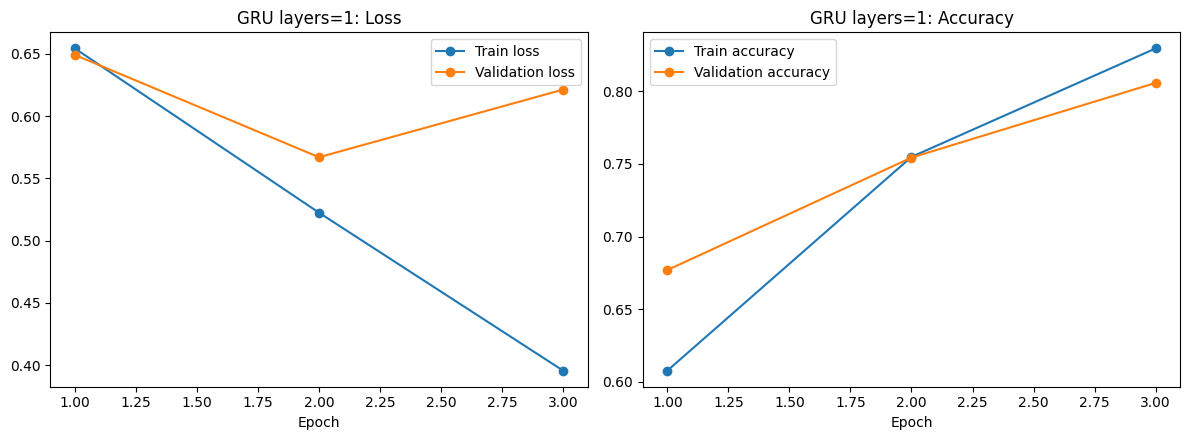

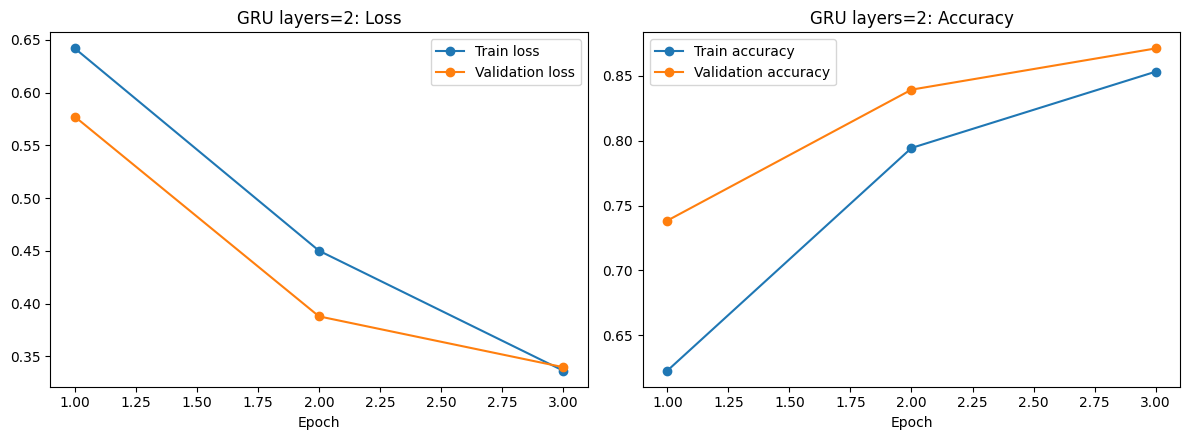

In [6]:
layer_results = []
layer_counts = [1, 2]
for num_layers in layer_counts:
    layer_results.append(
        train_model(
            variant=best_variant,
            embed_dim=EMBED_DIM,
            hidden_dim=HIDDEN_DIM,
            num_layers=num_layers,
            epochs=EPOCHS,
            dropout=DROPOUT,
            vocab_size=SELECTED_VOCAB_SIZE,
            vocab_sizes=VOCAB_SIZES,
            learning_rate=LEARNING_RATE,
            max_len=MAX_LEN,
            device=device,
            checkpoint_name=f"{best_variant}_{num_layers}layer.pt",
            curve_title=f"{best_variant.upper()} layers={num_layers}",
            figure_name=f"{best_variant}_{num_layers}layer_learning_curves.png",
        )
    )

layer_ablation_export = [
    {
        "model": row["model"],
        "variant": row["variant"],
        "num_layers": num_layers,
        "accuracy": row["accuracy"],
        "precision": row["precision"],
        "recall": row["recall"],
        "f1": row["f1"],
        "time_per_epoch_sec": row["time_per_epoch_sec"],
        "checkpoint_path": row["checkpoint_path"],
        "figure_path": row["figure_path"],
    }
    for row, num_layers in zip(layer_results, layer_counts)
]
pd.DataFrame(layer_ablation_export)


In [7]:
for row in variant_results:
    print(f"Model: {row['model']}")
    print(f"  Accuracy: {row['accuracy']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  Recall: {row['recall']:.4f}")
    print(f"  F1-score: {row['f1']:.4f}")
    print(f"  Time per epoch (sec): {row['time_per_epoch_sec']:.2f}")
    print(f"  Vocab size: {row['vocab_size']} | Max length: {row['max_len']}")
    print(f"  Figure path: {row['figure_path']}")
    print()


Model: Vanilla RNN
  Accuracy: 0.6677
  Precision: 0.6756
  Recall: 0.6452
  F1-score: 0.6601
  Time per epoch (sec): 115.84
  Vocab size: 30000 | Max length: 455
  Figure path: /Users/admin/Downloads/New project/checkpoints/figures/rnn_learning_curves.png

Model: LSTM
  Accuracy: 0.7757
  Precision: 0.7691
  Recall: 0.7880
  F1-score: 0.7784
  Time per epoch (sec): 135.38
  Vocab size: 30000 | Max length: 455
  Figure path: /Users/admin/Downloads/New project/checkpoints/figures/lstm_learning_curves.png

Model: GRU
  Accuracy: 0.8268
  Precision: 0.7839
  Recall: 0.9024
  F1-score: 0.8390
  Time per epoch (sec): 145.57
  Vocab size: 30000 | Max length: 455
  Figure path: /Users/admin/Downloads/New project/checkpoints/figures/gru_learning_curves.png



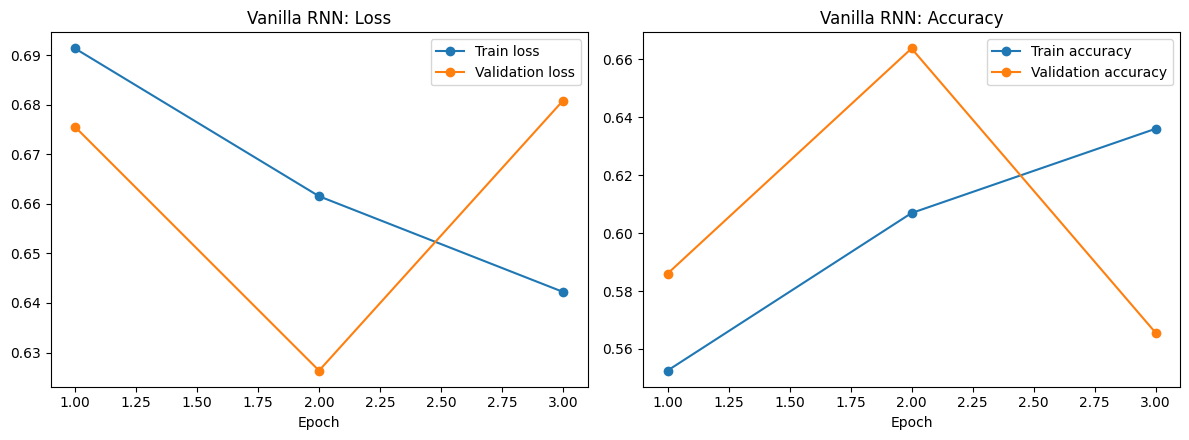

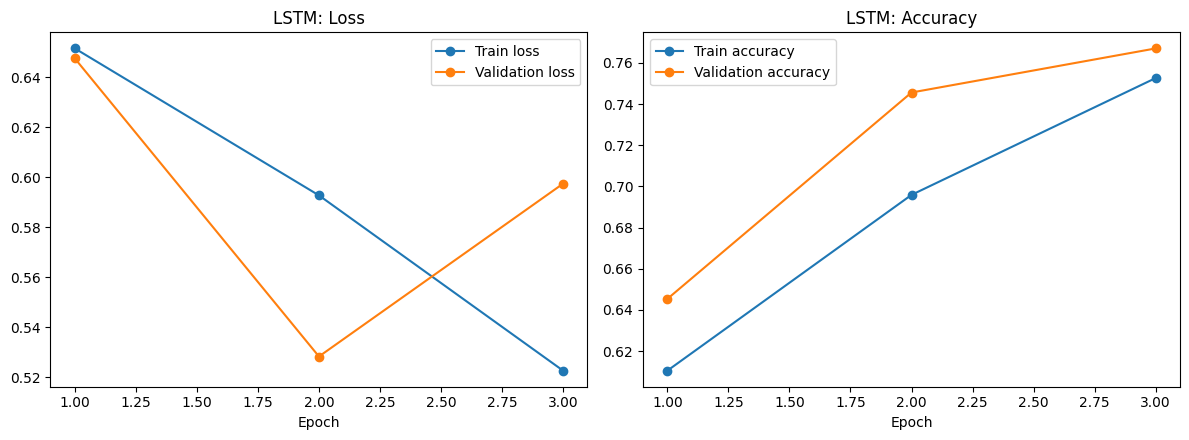

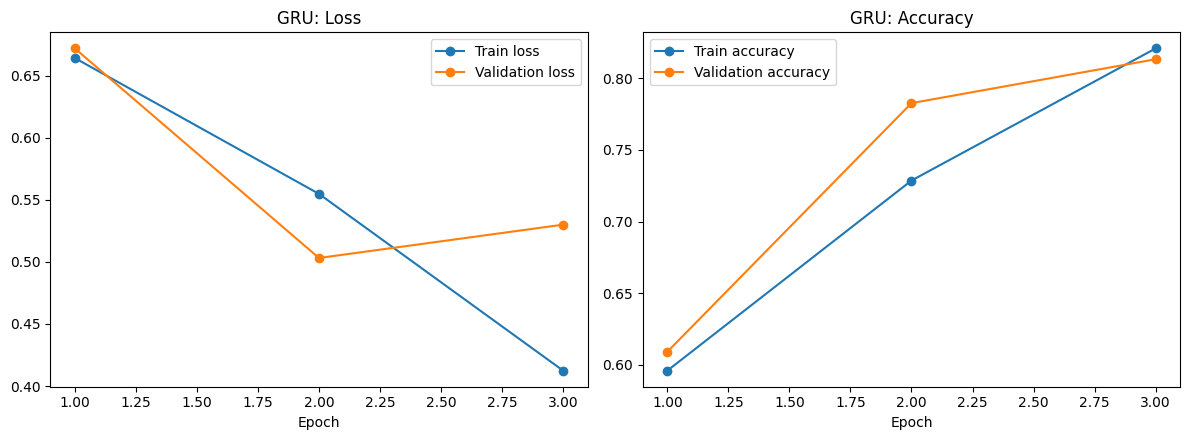

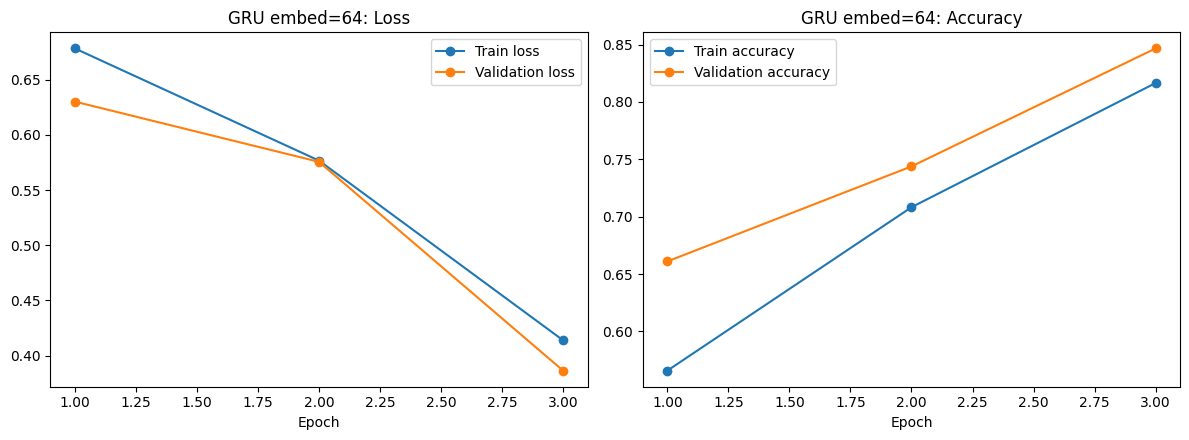

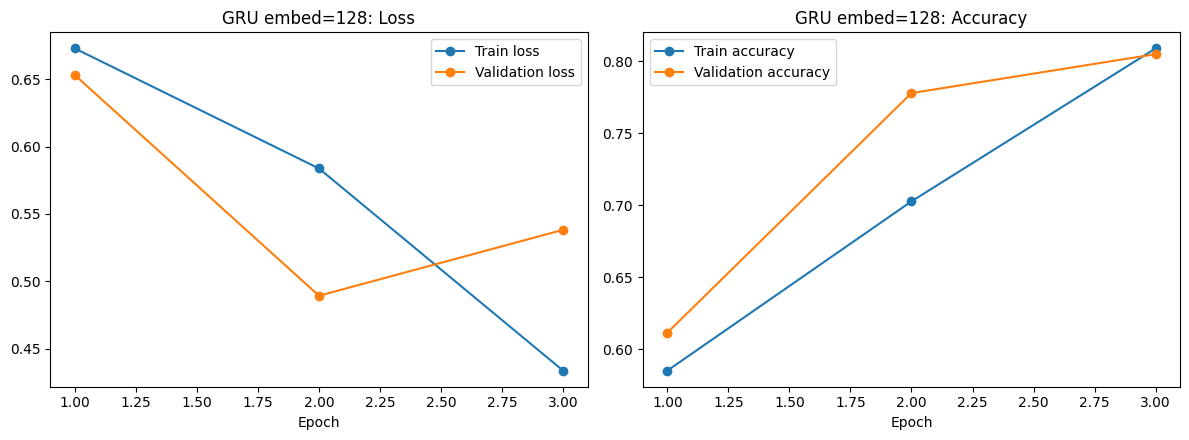

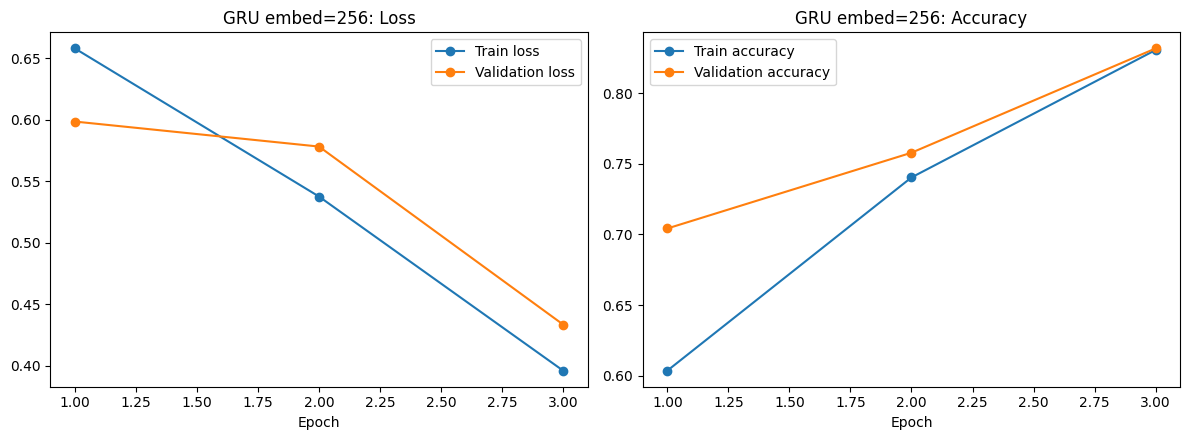

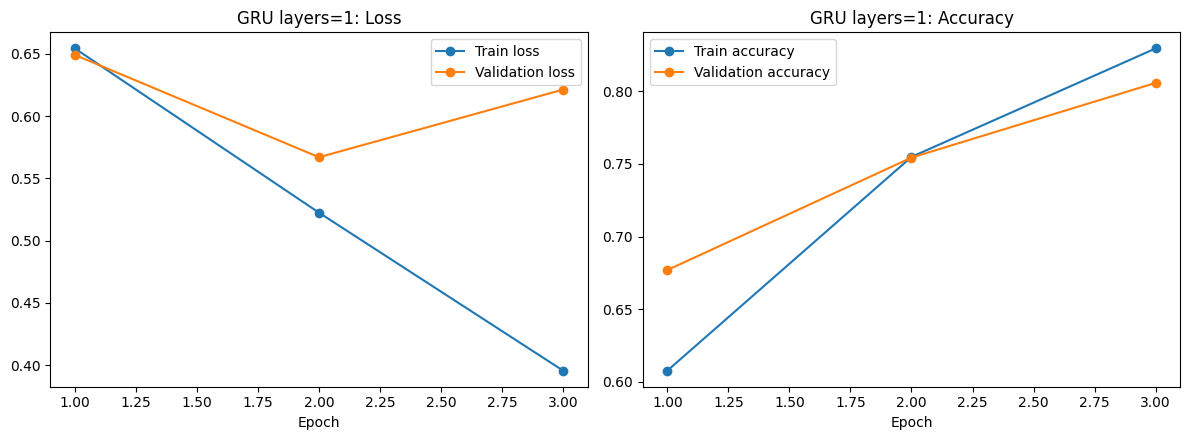

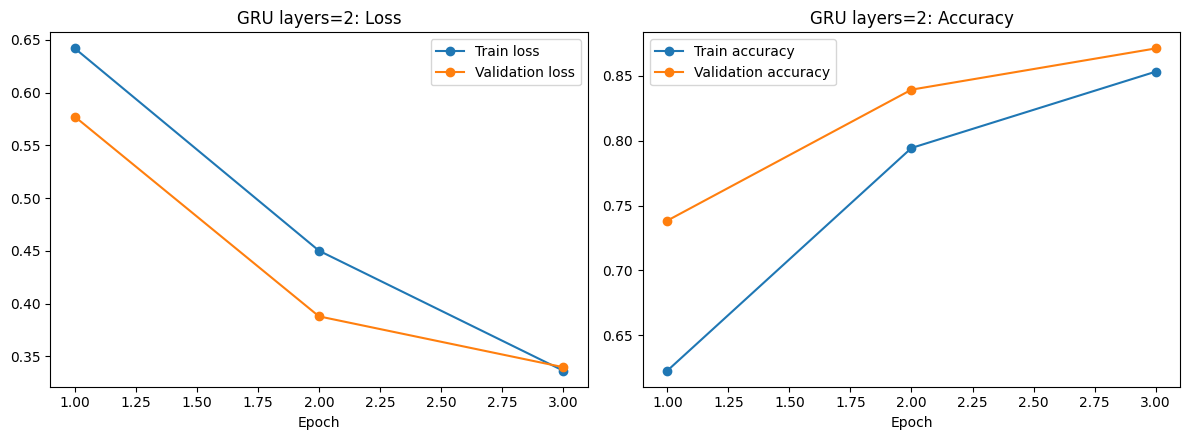

In [8]:
for group in [variant_results, embedding_results, layer_results]:
    for row in group:
        display(row["curve_figure"])
        plt.close(row["curve_figure"])


In [9]:
recurrent_results_export = [result_to_export_row(row) for row in variant_results]
figure_paths_export = {
    "variant_comparison": [
        {"model": row["model"], "figure_path": row["figure_path"]}
        for row in variant_results
    ],
    "embedding_ablation": [
        {"model": f"{row['model']} (embed={embed_dim})", "figure_path": row["figure_path"]}
        for row, embed_dim in zip(embedding_results, embedding_dims)
    ],
    "layer_ablation": [
        {"model": f"{row['model']} ({num_layers} layer)", "figure_path": row["figure_path"]}
        for row, num_layers in zip(layer_results, layer_counts)
    ],
}
best_model_misclassified_examples = best_recurrent_result["misclassified_df"].copy()
best_model_misclassified_examples.to_csv(MISCLASSIFIED_PATH, index=False)
canonical_best_path = CHECKPOINT_DIR / "rnn_best.pt"
shutil.copy(best_recurrent_result["checkpoint_path"], canonical_best_path)

recurrent_exports = {
    "recurrent_results_export": recurrent_results_export,
    "embedding_ablation_export": embedding_ablation_export,
    "layer_ablation_export": layer_ablation_export,
    "figure_paths_export": figure_paths_export,
    "best_recurrent_checkpoint": str(canonical_best_path),
    "best_recurrent_variant": best_variant,
}
EXPORT_PATH.write_text(json.dumps(recurrent_exports, indent=2))
recurrent_exports


{'recurrent_results_export': [{'model': 'Vanilla RNN',
   'variant': 'rnn',
   'accuracy': 0.6677,
   'precision': 0.6756020942408377,
   'recall': 0.6452,
   'f1': 0.6600511508951407,
   'time_per_epoch_sec': 115.84443195660909,
   'checkpoint_path': '/Users/admin/Downloads/New project/checkpoints/rnn_best.pt',
   'figure_path': '/Users/admin/Downloads/New project/checkpoints/figures/rnn_learning_curves.png'},
  {'model': 'LSTM',
   'variant': 'lstm',
   'accuracy': 0.7757,
   'precision': 0.7690806168260784,
   'recall': 0.788,
   'f1': 0.7784253679739208,
   'time_per_epoch_sec': 135.37752135594687,
   'checkpoint_path': '/Users/admin/Downloads/New project/checkpoints/lstm_best.pt',
   'figure_path': '/Users/admin/Downloads/New project/checkpoints/figures/lstm_learning_curves.png'},
  {'model': 'GRU',
   'variant': 'gru',
   'accuracy': 0.8268,
   'precision': 0.7838776928422516,
   'recall': 0.9024,
   'f1': 0.8389735961323912,
   'time_per_epoch_sec': 145.57005834579468,
   'check